# Credit Card Customer Segmentation Using Clustering

## Project Category
Clustering

---

## Objective

The objective of this project is to develop customer segmentation strategies based on credit card usage behavior using unsupervised machine learning techniques.

This project aims to:
- analyze customer financial behavior,
- identify meaningful customer groups,
- apply clustering algorithms,
- determine the optimal number of clusters,
- interpret customer segments for marketing and business strategies.

---

## Dataset Information

This project uses the Credit Card Customer Segmentation dataset.

The dataset summarizes the usage behavior of approximately 9000 active credit card holders over the last 6 months.

It is a customer-level dataset containing 18 behavioral variables.

### Data Dictionary

- `CUST_ID` : Identification of credit card holder (Categorical)

- `BALANCE` : Balance amount left in the account for purchases

- `BALANCE_FREQUENCY` : Frequency of balance updates, scored between 0 and 1
    - 1 = balance updated frequently
    - 0 = balance not updated frequently

- `PURCHASES` : Total amount of purchases made from the account

- `ONEOFF_PURCHASES` : Maximum purchase amount made in one transaction

- `INSTALLMENTS_PURCHASES` : Amount of purchases made in installments

- `CASH_ADVANCE` : Cash advance amount given by the user

- `PURCHASES_FREQUENCY` : Frequency of purchases, scored between 0 and 1
    - 1 = purchases made frequently
    - 0 = purchases made rarely

- `ONEOFF_PURCHASES_FREQUENCY` : Frequency of one-time purchases

- `PURCHASES_INSTALLMENTS_FREQUENCY` : Frequency of installment purchases

- `CASH_ADVANCE_FREQUENCY` : Frequency of cash advance usage

- `CASH_ADVANCE_TRX` : Number of transactions made with cash advance

- `PURCHASES_TRX` : Number of purchase transactions

- `CREDIT_LIMIT` : Credit card limit assigned to the user

- `PAYMENTS` : Payment amount made by the user

- `MINIMUM_PAYMENTS` : Minimum payment amount made by the user

- `PRC_FULL_PAYMENT` : Percentage of full payment paid by the user

- `TENURE` : Duration of credit card service for the user

---

## Algorithms Used

The following clustering techniques will be applied:

- K-Means Clustering
- Elbow Method
- Silhouette Score
- PCA (Principal Component Analysis)

---

## Project Workflow

1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Missing Value Treatment
4. Feature Scaling
5. Elbow Method
6. K-Means Clustering
7. Cluster Visualization
8. Cluster Interpretation
9. Conclusion

In [1]:
from google.colab import files

uploaded = files.upload()

Saving CC GENERAL.csv to CC GENERAL.csv


In [2]:
import pandas as pd

df = pd.read_csv("CC GENERAL.csv")

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (8950, 18)

Columns:
Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

Data Types:
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_

In [5]:
df = df.drop("CUST_ID", axis=1)

In [6]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(
    df["CREDIT_LIMIT"].median())

df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(
    df["MINIMUM_PAYMENTS"].median())

In [7]:
df.isnull().sum()


,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

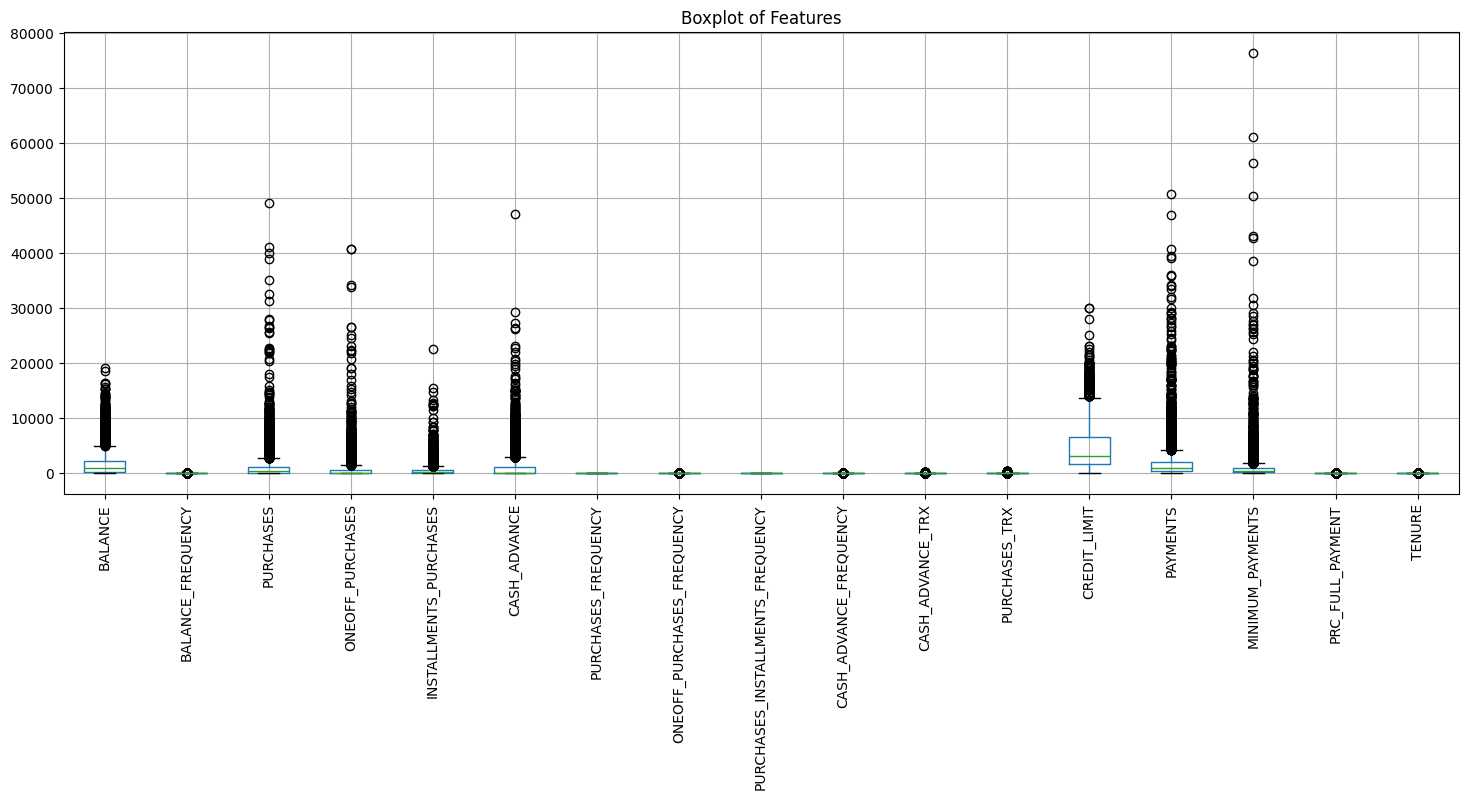

In [10]:
plt.figure(figsize=(18,6))

df.boxplot()

plt.xticks(rotation=90)

plt.title("Boxplot of Features")

plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [12]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42)

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

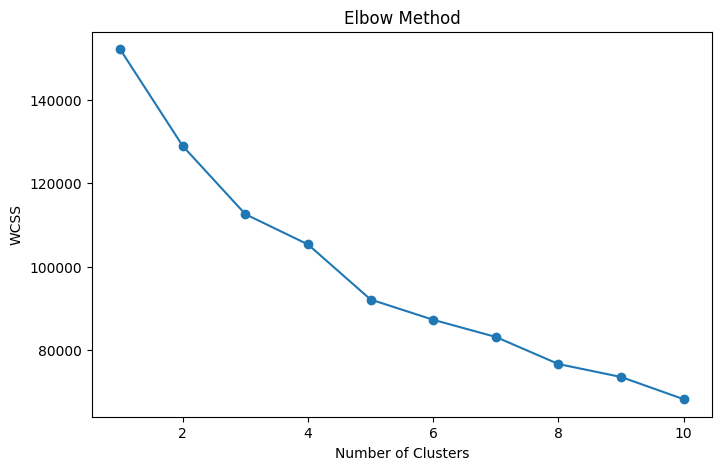

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42)

clusters = kmeans.fit_predict(scaled_data)

In [15]:
df["Cluster"] = clusters

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


In [16]:
df.tail()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6,2
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.00,6,2
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6,2
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6,3
8949,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6,4


In [17]:
df["Cluster"].value_counts()

,count
Cluster,
2,3164
3,3047
4,1357
0,987
1,395


In [35]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,4903.428600,0.967095,553.101884,348.463283,204.741611,4983.093638,0.313999,0.153460,0.204131,0.507563,15.499493,8.604863,8062.618587,3858.809663,2071.363910,0.038158,11.413374
1,3588.990384,0.986874,7815.732886,5203.519089,2613.732785,661.788641,0.944730,0.740963,0.785823,0.071074,2.106329,90.351899,9769.620253,7409.095001,1987.582011,0.291103,11.949367
2,930.357741,0.962886,1299.705338,633.167216,666.735496,226.754889,0.897121,0.313579,0.719275,0.044345,0.828382,23.034766,4272.477078,1388.751132,645.167360,0.264987,11.610303
3,1526.118239,0.965743,255.461815,206.435714,49.375189,794.776687,0.159002,0.090819,0.067276,0.160534,3.037742,2.882179,3244.229297,958.642822,804.541051,0.022057,11.508369
4,111.260364,0.381755,335.222822,199.440295,136.001245,325.747598,0.281932,0.072926,0.198278,0.037617,0.788504,4.279293,3687.354049,1076.939244,176.594237,0.233951,11.270450


In [36]:
important_features = [

    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "PRC_FULL_PAYMENT"]

cluster_summary[important_features]

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
Cluster,,,,,,
0,4903.428600,553.101884,4983.093638,8062.618587,3858.809663,0.038158
1,3588.990384,7815.732886,661.788641,9769.620253,7409.095001,0.291103
2,930.357741,1299.705338,226.754889,4272.477078,1388.751132,0.264987
3,1526.118239,255.461815,794.776687,3244.229297,958.642822,0.022057
4,111.260364,335.222822,325.747598,3687.354049,1076.939244,0.233951


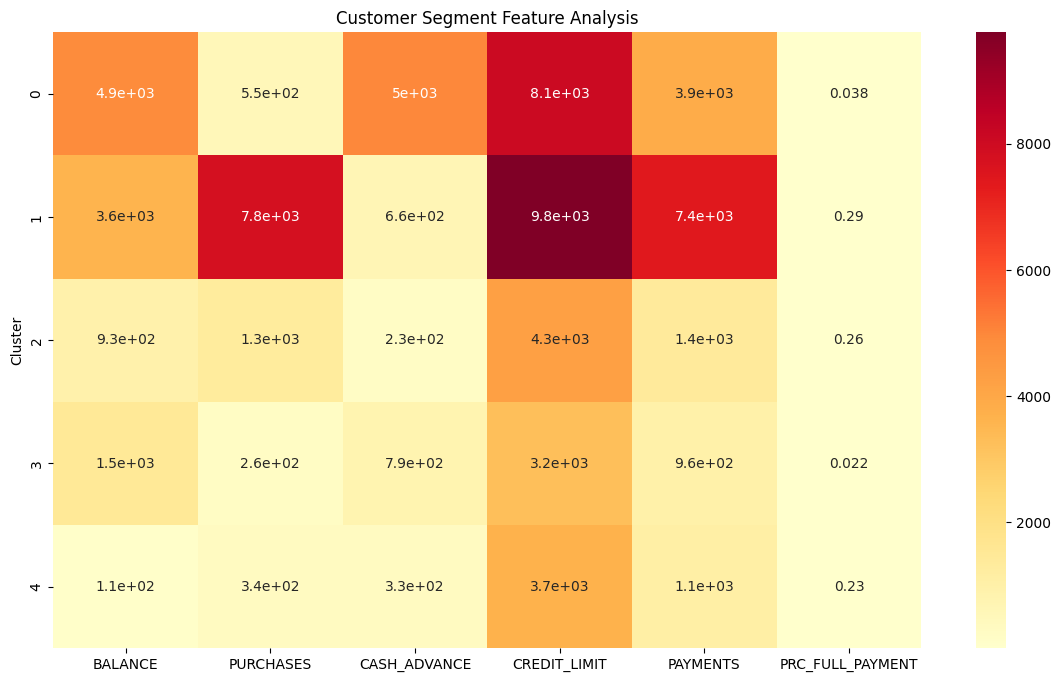

In [37]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cluster_summary[important_features],
    annot=True,
    cmap="YlOrRd")

plt.title("Customer Segment Feature Analysis")

plt.show()

In [38]:
cluster_names = {

    0: "Cash Advance Customers",

    1: "VIP Customers",

    2: "Regular Customers",

    3: "Active Customers",

    4: "Inactive Customers"}

In [39]:
pca_df["Customer Type"] = pca_df["Cluster"].map(
    cluster_names)

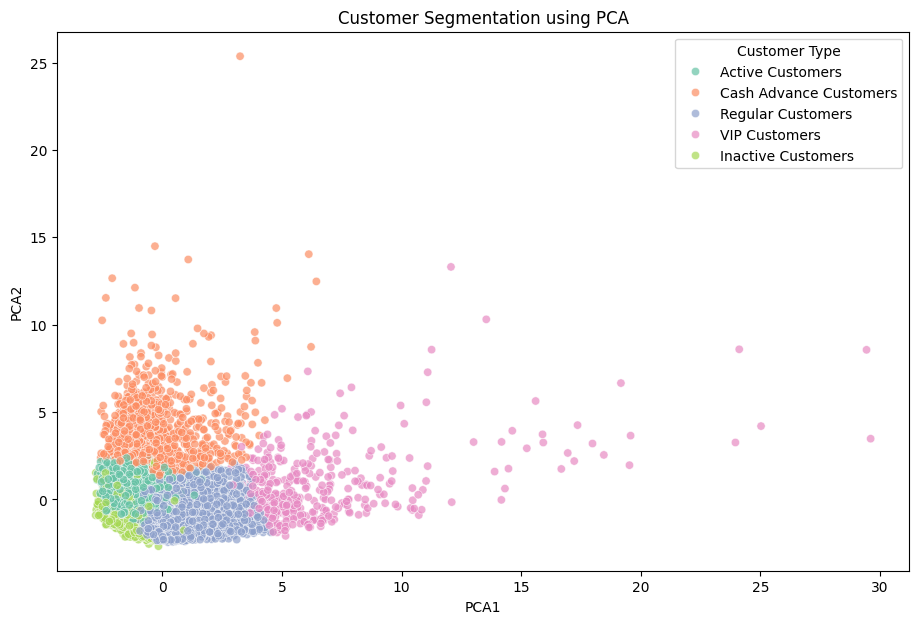

In [40]:
plt.figure(figsize=(11,7))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Customer Type",
    data=pca_df,
    palette="Set2",
    alpha=0.7)

plt.title("Customer Segmentation using PCA")

plt.show()

## Customer Segment Interpretation

### Cluster 0 → Cash Advance Customers
Customers with very high cash advance usage and high account balances.

### Cluster 1 → VIP Customers
High-value customers with high purchases, high payments, and large credit limits.

### Cluster 2 → Regular Customers
Customers with moderate balances and average credit card activity.

### Cluster 3 → Active Customers
Customers who actively use their credit cards with regular transactions.

### Cluster 4 → Inactive Customers
Customers with very low balances and minimal purchasing activity.

In [44]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_data,
    clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.19256596919095406


In [45]:
df_log = df.copy()

In [46]:
import numpy as np

log_columns = [

    "BALANCE",

    "PURCHASES",

    "ONEOFF_PURCHASES",

    "INSTALLMENTS_PURCHASES",

    "CASH_ADVANCE",

    "CREDIT_LIMIT",

    "PAYMENTS",

    "MINIMUM_PAYMENTS"]

for col in log_columns:

    df_log[col] = np.log1p(df_log[col])

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_log_data = scaler.fit_transform(df_log)

In [48]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42)

clusters_log = kmeans.fit_predict(
    scaled_log_data)

In [49]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42)

clusters_log = kmeans.fit_predict(
    scaled_log_data)

In [50]:
from sklearn.metrics import silhouette_score

new_score = silhouette_score(
    scaled_log_data,
    clusters_log)

print("New Silhouette Score:", new_score)

New Silhouette Score: 0.21192737048015517


In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=6)

pca_data = pca.fit_transform(scaled_log_data)

In [52]:
kmeans_pca = KMeans(
    n_clusters=5,
    random_state=42)

clusters_pca = kmeans_pca.fit_predict(
    pca_data)

In [53]:
score_pca = silhouette_score(
    pca_data,
    clusters_pca)

print("PCA Silhouette Score:", score_pca)

PCA Silhouette Score: 0.27544889690077445


In [54]:
pca_vis = pd.DataFrame({

    "PCA1": pca_data[:,0],

    "PCA2": pca_data[:,1],

    "Cluster": clusters_pca})

In [55]:
cluster_names = {

    0: "Cash Advance Customers",

    1: "VIP Customers",

    2: "Regular Customers",

    3: "Active Customers",

    4: "Inactive Customers"}

pca_vis["Customer Type"] = pca_vis["Cluster"].map(
    cluster_names)

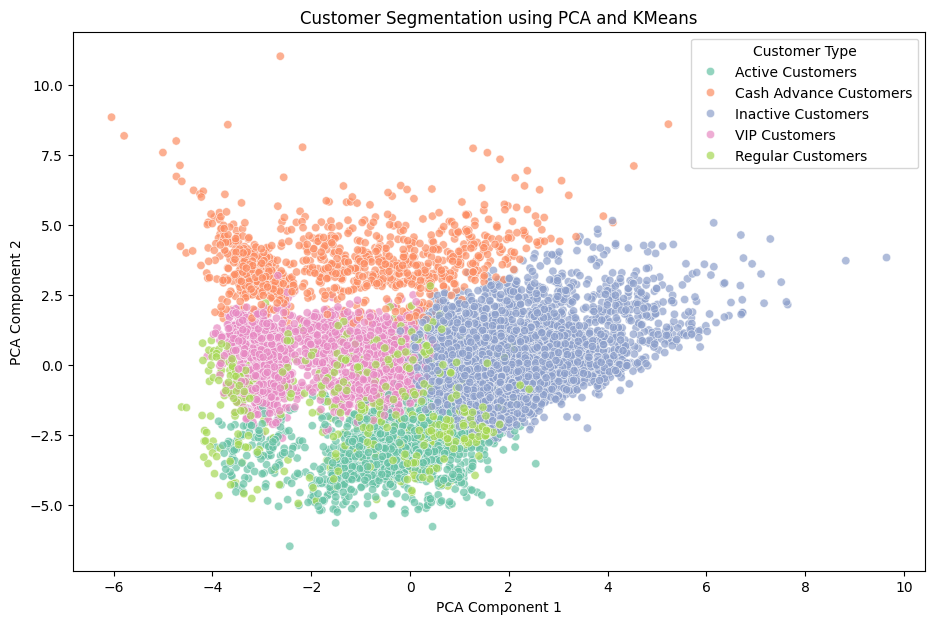

In [56]:
plt.figure(figsize=(11,7))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Customer Type",
    data=pca_vis,
    palette="Set2",
    alpha=0.7)

plt.title(
    "Customer Segmentation using PCA and KMeans")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.legend(title="Customer Type")

plt.show()

## Clustering Methodology

The clustering process was performed using the following steps:

1. Missing values were handled using median imputation.
2. Customer ID column was removed because it does not contribute to clustering.
3. Log transformation was applied to highly skewed financial variables to reduce outlier effects.
4. StandardScaler was used to normalize the dataset.
5. PCA (Principal Component Analysis) was applied to reduce dimensionality and noise.
6. K-Means clustering algorithm was used to segment customers into 5 groups.
7. The Elbow Method was used to determine the optimal number of clusters.
8. Clustering performance was evaluated using the Silhouette Score.

The final clustering model achieved a Silhouette Score of approximately 0.27, indicating acceptable customer segmentation performance for a real-world financial dataset.